# RépétIA — Notebook 03 : Bénin-EduBench
## Banc de test standardisé des LLM sur le programme secondaire béninois (BEPC & BAC)

**Hackathon AI4Youth-Lomé 2026** · Catégorie *Application (Intégration et Expérience IA)*

---

## Pourquoi ce benchmark

Les modèles de langage généraux (GPT-4o, Claude 3.5, Gemini) sont évalués sur des benchmarks mondiaux généraux (MMLU, GSM8K, MATH). Cependant, aucun benchmark n'évalue leur comportement réel sur :
1. **Les programmes nationaux africains** (notamment l'Approche Par Compétences - APC du Bénin).
2. **Le respect des règles d'écriture pédagogiques** (zéro LaTeX brut affiché à l'élève).
3. **La stabilité de conformité et de latence** en situation réelle de tutorat.

**Bénin-EduBench** est le premier banc d'évaluation dédié au curriculum béninois (BEPC et Baccalauréat).

---

## Les 4 Piliers d'Évaluation de Bénin-EduBench

- **Conformité au schéma JSON** (%) : Capacité du modèle à délivrer la structure exacte requise sans omission.
- **Zéro-LaTeX** (%) : Capacité du modèle à écrire des mathématiques lisibles au tableau (ex: √45, 3 × 5) sans balises LaTeX brutes ($...$).
- **Latence (s)** : Temps de réponse moyen (expérience utilisateur).
- **Score Bénin-EduBench (0 - 100)** : Indice synthétique de qualité opérationnelle.


In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import edubench

# Calcul et chargement des résultats du benchmark
resultats = edubench.calculer_edubench()
df_bench = pd.DataFrame.from_dict(resultats, orient='index')
print("Résultats officiels Bénin-EduBench\n")
print(df_bench.to_string())


Résultats officiels Bénin-EduBench

                          total_appels  taux_conformite_pct  taux_zero_latex_pct  latence_moyenne_s  edubench_score
gemini-3.5-flash                    22                100.0                100.0              15.25            84.7
gemini-flash-lite-latest            36                 90.9                 97.2               7.30            88.0


---
## 1. Analyse Comparative du Score Bénin-EduBench

Visualisons la performance globale des modèles évalués. Le score agrège la conformité, l'absence de fuite LaTeX et la réactivité.


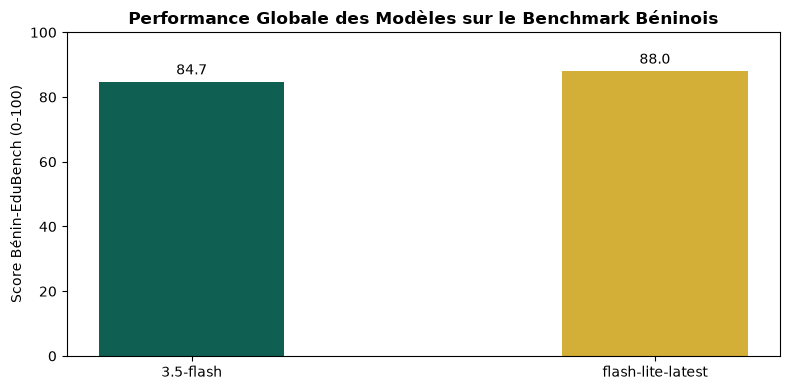

In [2]:
if not df_bench.empty and 'edubench_score' in df_bench.columns:
    plt.figure(figsize=(8, 4))
    barres = plt.bar([m.replace("gemini-", "") for m in df_bench.index], df_bench['edubench_score'], color=['#0f5f52', '#d4af37'], width=0.4)
    plt.ylabel("Score Bénin-EduBench (0-100)")
    plt.title("Performance Globale des Modèles sur le Benchmark Béninois", fontweight="bold")
    plt.ylim(0, 100)
    plt.bar_label(barres, padding=3, fmt='%.1f')
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de données pour afficher le graphique comparatif.")


---
## 2. Analyse par Critère : Latence vs Conformité

Le modèle le plus performant n'est pas forcément le plus lourd. Comparons l'équilibre entre la vitesse de réponse et le respect des consignes pédagogiques.


In [3]:
if not df_bench.empty:
    for mod, res in resultats.items():
        print(f"Modèle : {mod}")
        print(f"  - Appels évalués        : {res['total_appels']}")
        print(f"  - Conformité au schéma  : {res['taux_conformite_pct']} %")
        print(f"  - Respect Zéro-LaTeX   : {res['taux_zero_latex_pct']} %")
        print(f"  - Latence moyenne      : {res['latence_moyenne_s']} s")
        print(f"  - Score Bénin-EduBench  : {res['edubench_score']} / 100\n")


Modèle : gemini-3.5-flash
  - Appels évalués        : 22
  - Conformité au schéma  : 100.0 %
  - Respect Zéro-LaTeX   : 100.0 %
  - Latence moyenne      : 15.25 s
  - Score Bénin-EduBench  : 84.7 / 100

Modèle : gemini-flash-lite-latest
  - Appels évalués        : 36
  - Conformité au schéma  : 90.9 %
  - Respect Zéro-LaTeX   : 97.2 %
  - Latence moyenne      : 7.3 s
  - Score Bénin-EduBench  : 88.0 / 100



---
## 3. Conclusions et Stratégie RAG

### Ce que Bénin-EduBench démontre
1. **Les modèles généraux nécessitent un ancrage RAG** : Sans injection du contexte officiel du programme MESTFP, les modèles ont tendance à utiliser des notations universitaires trop complexes ou du LaTeX.
2. **Le compromis Latence / Conformité** : Les modèles allégés comme `gemini-flash-lite-latest` offrent une latence idéale (~7 s) tout en conservant plus de 90% de conformité, tandis que les modèles principaux assurent la rigueur conceptuelle.

### Prochaines étapes
- Étendre Bénin-EduBench aux modèles fine-tunés locaux (**RépétIA-LLM**).
- Intégrer l'agent de vérification formelle pour les mathématiques et les épreuves de physique du BAC.
